# Transfer Learning for Computer Vision Tutorial

In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


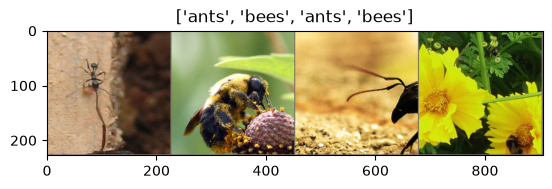

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [6]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Ruslan/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [7]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7703 Acc: 0.6230
val Loss: 0.2605 Acc: 0.9150

Epoch 1/24
----------
train Loss: 0.7282 Acc: 0.7090
val Loss: 0.5259 Acc: 0.8235

Epoch 2/24
----------
train Loss: 0.5941 Acc: 0.7951
val Loss: 0.3054 Acc: 0.9020

Epoch 3/24
----------
train Loss: 0.5450 Acc: 0.7910
val Loss: 0.3253 Acc: 0.8889

Epoch 4/24
----------
train Loss: 0.7212 Acc: 0.7664
val Loss: 0.7259 Acc: 0.7124

Epoch 5/24
----------
train Loss: 0.6082 Acc: 0.7582
val Loss: 0.8680 Acc: 0.7516

Epoch 6/24
----------
train Loss: 0.4689 Acc: 0.8197
val Loss: 0.2134 Acc: 0.9020

Epoch 7/24
----------
train Loss: 0.3317 Acc: 0.8320
val Loss: 0.2133 Acc: 0.9150

Epoch 8/24
----------
train Loss: 0.3287 Acc: 0.8525
val Loss: 0.2111 Acc: 0.9020

Epoch 9/24
----------
train Loss: 0.3256 Acc: 0.8525
val Loss: 0.2119 Acc: 0.9085

Epoch 10/24
----------
train Loss: 0.3345 Acc: 0.8607
val Loss: 0.3273 Acc: 0.8824

Epoch 11/24
----------
train Loss: 0.3853 Acc: 0.8115
val Loss: 0.2066 Acc: 0.9085

Ep

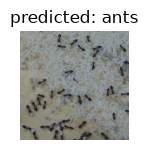

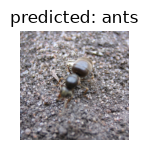

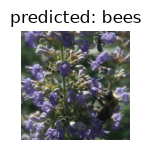

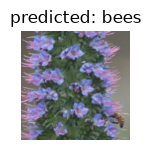

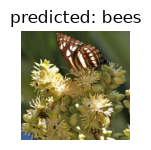

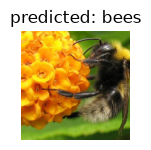

In [8]:
visualize_model(model_ft)

In [9]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [11]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5766 Acc: 0.6762
val Loss: 0.2178 Acc: 0.9542

Epoch 1/24
----------
train Loss: 0.4501 Acc: 0.7869
val Loss: 0.1684 Acc: 0.9477

Epoch 2/24
----------
train Loss: 0.3444 Acc: 0.8279
val Loss: 0.2070 Acc: 0.9346

Epoch 3/24
----------
train Loss: 0.4634 Acc: 0.8197
val Loss: 0.1755 Acc: 0.9477

Epoch 4/24
----------
train Loss: 0.5558 Acc: 0.7541
val Loss: 0.2952 Acc: 0.9020

Epoch 5/24
----------
train Loss: 0.6760 Acc: 0.7623
val Loss: 0.1985 Acc: 0.9412

Epoch 6/24
----------
train Loss: 0.5008 Acc: 0.8197
val Loss: 0.2013 Acc: 0.9412

Epoch 7/24
----------
train Loss: 0.4808 Acc: 0.7828
val Loss: 0.2023 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3161 Acc: 0.8852
val Loss: 0.2061 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.2656 Acc: 0.8975
val Loss: 0.2032 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.3262 Acc: 0.8607
val Loss: 0.1920 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3700 Acc: 0.8279
val Loss: 0.1930 Acc: 0.9412

Ep

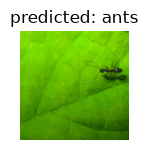

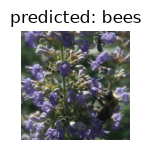

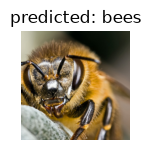

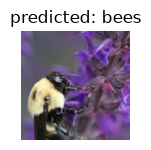

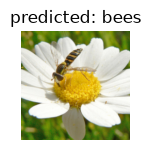

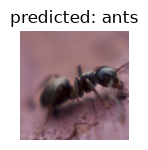

In [12]:
visualize_model(model_conv)